# Setup & Import

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# LOAD DATASET
file_path = '/content/drive/MyDrive/A-VISS/merged_data.csv'

df = pd.read_csv(file_path, low_memory=False)
df['datetime'] = pd.to_datetime(df['datetime'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11509051 entries, 0 to 11509050
Data columns (total 9 columns):
 #   Column    Dtype         
---  ------    -----         
 0   X         float64       
 1   Y         float64       
 2   Z         float64       
 3   EDA       float64       
 4   HR        float64       
 5   TEMP      float64       
 6   id        object        
 7   datetime  datetime64[ns]
 8   label     float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 790.3+ MB


In [ ]:
df.isna().sum()

,0
X,0
Y,0
Z,0
EDA,0
HR,0
TEMP,0
id,0
datetime,0
label,0


In [ ]:
df.loc[(df['HR'] <= 30) | (df['HR'] >= 220), 'HR'] = np.nan
df['HR'] = df['HR'].interpolate(method='linear') # Isi kembali yang tadi di-NaN-kan

print("\nJumlah missing values setelah dibersihkan:\n", df.isna().sum())


Jumlah missing values setelah dibersihkan:
 X           0
Y           0
Z           0
EDA         0
HR          0
TEMP        0
id          0
datetime    0
label       0
dtype: int64


# Resampling & Feature Extraction

In [ ]:
def get_mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

agg_dict = {
    'HR': ['mean', 'std', 'max', 'min'],
    'EDA': ['mean', 'std', 'max', 'min'],
    'TEMP': ['mean', 'std'],
    'X': ['std'],
    'Y': ['std'],
    'Z': ['std'],
    'label': get_mode
}

In [ ]:
df_resampled = df.groupby('id').resample('1Min', on='datetime').agg(agg_dict).dropna()

df_resampled.columns = ['_'.join(col).strip() for col in df_resampled.columns.values]
df_resampled = df_resampled.rename(columns={'label_get_mode': 'label'}).reset_index()

print("Bentuk data setelah resampling:", df_resampled.shape)
print("\nContoh hasil fitur untuk XGBoost:")
print(df_resampled.head())

Bentuk data setelah resampling: (5946, 16)

Contoh hasil fitur untuk XGBoost:
   id            datetime    HR_mean    HR_std  HR_max  HR_min  EDA_mean  \
0  15 2020-07-08 13:09:00  73.306167  1.754962   77.27   69.40  2.229548   
1  15 2020-07-08 13:10:00  69.256833  1.101266   73.10   67.97  3.648911   
2  15 2020-07-08 13:11:00  76.615667  1.420746   79.25   73.57  3.568696   
3  15 2020-07-08 13:12:00  77.727333  1.299616   79.32   74.28  4.013080   
4  15 2020-07-08 13:13:00  70.472167  1.884526   74.10   67.88  4.545269   

    EDA_std   EDA_max   EDA_min  TEMP_mean  TEMP_std      X_std      Y_std  \
0  1.116913  3.697039  0.000000  32.438667  0.136923  10.890684  18.999821   
1  0.496939  4.405046  2.204646  32.571500  0.189327  10.299269  10.379553   
2  0.692795  4.880928  2.437987  32.664167  0.446596  12.911116  13.049549   
3  0.583623  5.264712  2.294460  32.595833  0.098570  16.003018  24.032474   
4  0.253301  5.216015  3.935192  32.610667  0.063311  13.618140   9.413524 

# Machine Learning Preprocessing

In [ ]:
!pip install catboost

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import numpy as np

X = df_resampled.drop(columns=['id', 'datetime', 'label'])
y = df_resampled['label']
groups = df_resampled['id']

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

logo = LeaveOneGroupOut()
scaler = StandardScaler()

overall_results = {
    name: {'acc': [], 'f1': [], 'recall': []} for name in models.keys()
}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


# Model Benchmarking

In [ ]:
for train_idx, test_idx in logo.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)

        overall_results[name]['acc'].append(acc)
        overall_results[name]['f1'].append(f1)
        overall_results[name]['recall'].append(rec)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:22:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:23:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:23:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters

In [ ]:
print("=== HASIL BENCHMARK MODEL A-VISS (LOSO EVALUATION) ===")
for name in overall_results.keys():
    mean_acc = np.mean(overall_results[name]['acc'])
    mean_f1 = np.mean(overall_results[name]['f1'])
    mean_rec = np.mean(overall_results[name]['recall'])

    print(f"Model: {name}")
    print(f"  - Akurasi : {mean_acc:.4f} ({mean_acc*100:.2f}%)")
    print(f"  - F1-Score: {mean_f1:.4f}")
    print(f"  - Recall  : {mean_rec:.4f}")
    print("-" * 50)

=== HASIL BENCHMARK MODEL A-VISS (LOSO EVALUATION) ===
Model: Random Forest
  - Akurasi : 0.6962 (69.62%)
  - F1-Score: 0.6672
  - Recall  : 0.6962
--------------------------------------------------
Model: XGBoost
  - Akurasi : 0.6791 (67.91%)
  - F1-Score: 0.6655
  - Recall  : 0.6791
--------------------------------------------------
Model: LightGBM
  - Akurasi : 0.6752 (67.52%)
  - F1-Score: 0.6588
  - Recall  : 0.6752
--------------------------------------------------
Model: CatBoost
  - Akurasi : 0.6881 (68.81%)
  - F1-Score: 0.6695
  - Recall  : 0.6881
--------------------------------------------------


# Time Series Preprocessing

## Load Data

In [ ]:
def load_and_clean_data(file_path):
    print("Loading and cleaning raw data...")
    df = pd.read_csv(file_path, low_memory=False)
    df['datetime'] = pd.to_datetime(df['datetime'])

    # Interpolasi untuk sensor cols
    sensor_cols = ['X', 'Y', 'Z', 'EDA', 'HR', 'TEMP']
    df[sensor_cols] = df[sensor_cols].interpolate(method='linear', limit_direction='both')

    # Filtering HR anomali
    df.loc[(df['HR'] < 40) | (df['HR'] > 200), 'HR'] = np.nan
    df['HR'] = df['HR'].interpolate(method='linear')

    # Optimasi Tipe Data
    df[sensor_cols] = df[sensor_cols].astype('float32')
    df['label'] = df['label'].astype('int8')

    return df.dropna(subset=['label'])

# Load Data Utama
df = load_and_clean_data(file_path)
display(df.info())

Loading and cleaning raw data...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11509051 entries, 0 to 11509050
Data columns (total 9 columns):
 #   Column    Dtype         
---  ------    -----         
 0   X         float32       
 1   Y         float32       
 2   Z         float32       
 3   EDA       float32       
 4   HR        float32       
 5   TEMP      float32       
 6   id        object        
 7   datetime  datetime64[ns]
 8   label     int8          
dtypes: datetime64[ns](1), float32(6), int8(1), object(1)
memory usage: 450.0+ MB


None

## Resampling

In [ ]:
def extract_features(df):
    def get_mode(x):
        return x.mode().iloc[0] if not x.mode().empty else np.nan

    agg_dict = {
        'HR': ['mean', 'std', 'max'], # std HR merepresentasikan HRV
        'EDA': ['mean', 'std', 'max'],
        'TEMP': ['mean'],
        'X': ['std'], 'Y': ['std'], 'Z': ['std'], # Aktivitas fisik
        'label': get_mode
    }

    # Resampling per ID dan per Menit
    df_res = df.groupby('id').resample('1Min', on='datetime').agg(agg_dict).dropna()
    df_res.columns = ['_'.join(col).strip() for col in df_res.columns.values]
    df_res = df_res.rename(columns={'label_get_mode': 'label'}).reset_index()
    return df_res

# Machine Learning & LSTM Benchmarking

In [ ]:
def create_sequences(X_scaled, y_series, groups_series, time_steps=5):
    X_seq, y_seq, g_seq = [], [], []
    for group_id in groups_series.unique():
        idx = groups_series == group_id
        X_group = X_scaled[idx]
        y_group = y_series[idx].values

        if len(X_group) > time_steps:
            for i in range(len(X_group) - time_steps):
                X_seq.append(X_group[i : i + time_steps])
                y_seq.append(y_group[i + time_steps])
                g_seq.append(group_id)
    return np.array(X_seq), np.array(y_seq), np.array(g_seq)

In [ ]:
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

def build_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
df_raw = load_and_clean_data(file_path)
df_resampled = extract_features(df_raw)

X = df_resampled.drop(columns=['id', 'datetime', 'label'])
y = df_resampled['label'].astype(int)
groups = df_resampled['id']

logo = LeaveOneGroupOut()
scaler = StandardScaler()

# Inisialisasi Model dengan Optimasi Imbalance
models = {
    "Random Forest (Balanced)": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "XGBoost (Optimized)": XGBClassifier(scale_pos_weight=(len(y[y==0])/len(y[y==1])), eval_metric='logloss'),
    "LightGBM (Balanced)": LGBMClassifier(class_weight='balanced', importance_type='gain', verbose=-1),
    "CatBoost (Weighted)": CatBoostClassifier(auto_class_weights='Balanced', verbose=0)
}

results = {name: {'acc': [], 'f1': [], 'rec': []} for name in list(models.keys()) + ['LSTM (Time-Series)']}

Loading and cleaning raw data...


In [ ]:
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping

for train_idx, test_idx in logo.split(X, y, groups):
    # Split Data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Scaling
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # 1. Klasikal ML
    for name, model in models.items():
        # Fix XGBoost multiclass warning if needed by setting objective
        if "XGBoost" in name:
            model.set_params(objective='multi:softprob', num_class=3, scale_pos_weight=None)

        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)
        results[name]['acc'].append(accuracy_score(y_test, preds))
        results[name]['f1'].append(f1_score(y_test, preds, average='weighted', zero_division=0))
        results[name]['rec'].append(recall_score(y_test, preds, average='weighted', zero_division=0))

    # 2. LSTM (Time-Series)
    time_steps = 5
    X_tr_seq, y_tr_seq, _ = create_sequences(X_train_s, y_train, groups.iloc[train_idx], time_steps)
    X_te_seq, y_te_seq, _ = create_sequences(X_test_s, y_test, groups.iloc[test_idx], time_steps)

    if len(X_te_seq) > 0:
        model_lstm = build_lstm((time_steps, X_tr_seq.shape[2]))

        # Use part of training for validation to enable EarlyStopping
        val_split = int(len(X_tr_seq) * 0.8)
        X_tr, X_val = X_tr_seq[:val_split], X_tr_seq[val_split:]
        y_tr, y_val = y_tr_seq[:val_split], y_tr_seq[val_split:]

        cw = dict(enumerate(class_weight.compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)))

        model_lstm.fit(X_tr, y_tr, epochs=15, batch_size=32, verbose=0,
                       class_weight=cw, validation_data=(X_val, y_val),
                       callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)])

        l_preds = (model_lstm.predict(X_te_seq, verbose=0) > 0.5).astype(int)
        # If multiclass, LSTM needs argmax or categorical loss. Assuming binary for sigmoid output used in build_lstm.
        results['LSTM (Time-Series)']['acc'].append(accuracy_score(y_te_seq, l_preds))
        results['LSTM (Time-Series)']['f1'].append(f1_score(y_te_seq, l_preds, average='weighted', zero_division=0))
        results['LSTM (Time-Series)']['rec'].append(recall_score(y_te_seq, l_preds, average='weighted', zero_division=0))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:36:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was f

In [ ]:
print("\n" + "="*50)
print("HASIL KOMPARASI MODEL A-VISS (OPTIMIZED)")
print("="*50)
for name, metrics in results.items():
    if metrics['acc']: # Pastikan ada data
        print(f"MODEL: {name}")
        print(f"  > Akurasi : {np.mean(metrics['acc']):.4f}")
        print(f"  > F1-Score : {np.mean(metrics['f1']):.4f}")
        print(f"  > Recall   : {np.mean(metrics['rec']):.4f}")
        print("-" * 30)


HASIL KOMPARASI MODEL A-VISS (OPTIMIZED)
MODEL: Random Forest (Balanced)
  > Akurasi : 0.7298
  > F1-Score : 0.6921
  > Recall   : 0.7298
------------------------------
MODEL: XGBoost (Optimized)
  > Akurasi : 0.6865
  > F1-Score : 0.6766
  > Recall   : 0.6865
------------------------------
MODEL: LightGBM (Balanced)
  > Akurasi : 0.5873
  > F1-Score : 0.6232
  > Recall   : 0.5873
------------------------------
MODEL: CatBoost (Weighted)
  > Akurasi : 0.6153
  > F1-Score : 0.6447
  > Recall   : 0.6153
------------------------------
MODEL: LSTM (Time-Series)
  > Akurasi : 0.0596
  > F1-Score : 0.0350
  > Recall   : 0.0596
------------------------------


# Stacking Classifier Experiment

In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score
import numpy as np

estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)),
    ('xgb', XGBClassifier(scale_pos_weight=(len(y[y==0])/len(y[y==1])), eval_metric='logloss', random_state=42))
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=3,
    n_jobs=-1)

stacking_results = {'acc': [], 'f1': [], 'rec': []}

print("Memulai evaluasi LOSO khusus untuk Stacking Classifier...")

for train_idx, test_idx in logo.split(X, y, groups):
    # Split Data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Normalisasi
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Training Stacking
    stacking_clf.fit(X_train_s, y_train)

    # Prediksi
    preds = stacking_clf.predict(X_test_s)

    # Simpan hasil
    stacking_results['acc'].append(accuracy_score(y_test, preds))
    stacking_results['f1'].append(f1_score(y_test, preds, average='weighted', zero_division=0))
    stacking_results['rec'].append(recall_score(y_test, preds, average='weighted', zero_division=0))

Memulai evaluasi LOSO khusus untuk Stacking Classifier...


In [ ]:
print("="*50)
print("HASIL AKHIR STACKING CLASSIFIER A-VISS")
print("="*50)
print(f"MODEL: Stacking (Random Forest + XGBoost -> Logistic Regression)")
print(f"  > Akurasi : {np.mean(stacking_results['acc']):.4f}")
print(f"  > F1-Score: {np.mean(stacking_results['f1']):.4f}")
print(f"  > Recall  : {np.mean(stacking_results['rec']):.4f}")
print("-" * 50)

HASIL AKHIR STACKING CLASSIFIER A-VISS
MODEL: Stacking (Random Forest + XGBoost -> Logistic Regression)
  > Akurasi : 0.3938
  > F1-Score: 0.4551
  > Recall  : 0.3938
--------------------------------------------------


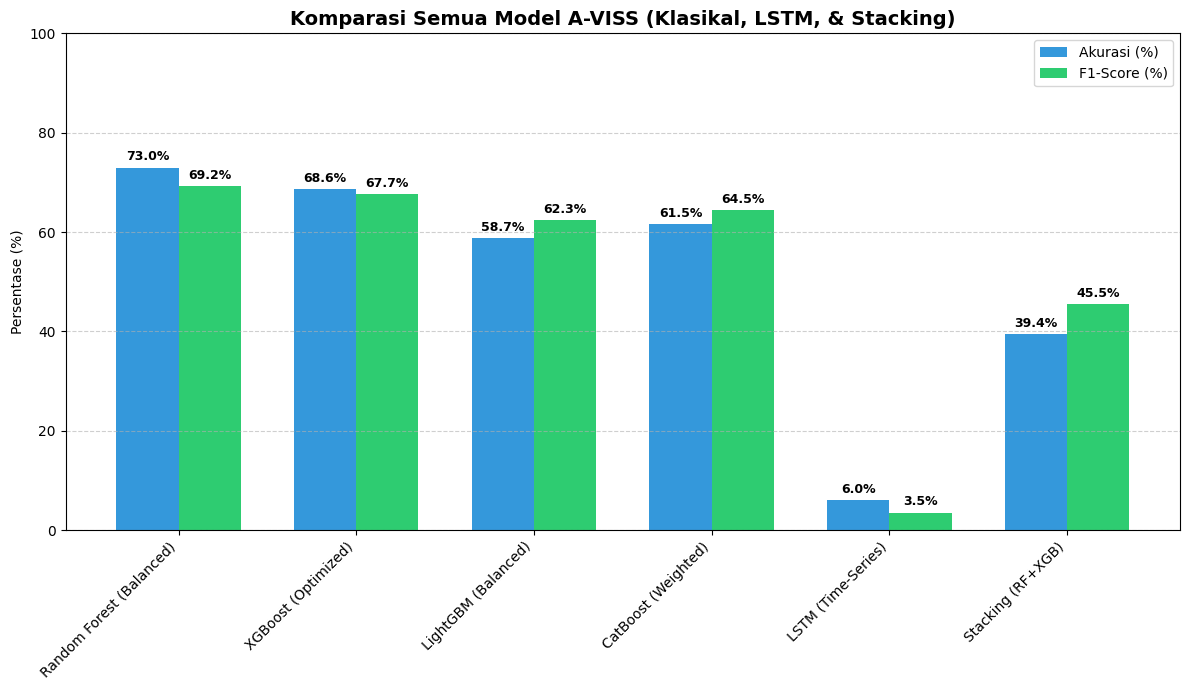

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Kumpulkan data dari dictionary 'results'
comparison_data = {}
for model_name, metrics in results.items():
    comparison_data[model_name] = {
        'acc': np.mean(metrics['acc']) * 100,
        'f1': np.mean(metrics['f1']) * 100
    }

# 2. Tambahkan data dari 'stacking_results'
comparison_data['Stacking (RF+XGB)'] = {
    'acc': np.mean(stacking_results['acc']) * 100,
    'f1': np.mean(stacking_results['f1']) * 100
}

# Persiapkan data untuk plotting
labels = list(comparison_data.keys())
acc_values = [v['acc'] for v in comparison_data.values()]
f1_values = [v['f1'] for v in comparison_data.values()]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, acc_values, width, label='Akurasi (%)', color='#3498db')
rects2 = ax.bar(x + width/2, f1_values, width, label='F1-Score (%)', color='#2ecc71')

# Tambahkan teks, judul, dan label
ax.set_ylabel('Persentase (%)')
ax.set_title('Komparasi Semua Model A-VISS (Klasikal, LSTM, & Stacking)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylim(0, 100)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Deep Learning Initial Test

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import gc
from sklearn.preprocessing import StandardScaler
from google.colab import drive

drive.mount('/content/drive')

warnings.filterwarnings('ignore')

path_simpan = '/content/drive/MyDrive/A-VISS/'

df = pd.read_csv(path_simpan + 'merged_data.csv', low_memory=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# OPTIMASI MEMORI & STANDARISASI SENSOR
sensor_cols = ['HR', 'EDA', 'TEMP', 'X', 'Y', 'Z']

# Paksa tipe data menjadi paling kecil untuk menyelamatkan RAM
df[sensor_cols] = df[sensor_cols].astype('float32')
df['label'] = df['label'].astype('int8')
df['datetime'] = pd.to_datetime(df['datetime'])
gc.collect()

0

# Standarisasi Per Subjek

In [7]:
sensor_cols = ['HR', 'EDA', 'TEMP', 'X', 'Y', 'Z']
list_scaled = []
unique_ids = df['id'].unique()

for uid in unique_ids:
    df_subset = df[df['id'] == uid].copy()
    scaler = StandardScaler()
    df_subset[sensor_cols] = scaler.fit_transform(df_subset[sensor_cols])
    list_scaled.append(df_subset)

df_final_scaled = pd.concat(list_scaled, ignore_index=True)
del list_scaled, df
gc.collect()

# Simpan hasil standarisasi agar bisa dipanggil mmap nanti
file_raw_scaled = path_simpan + 'dataset_raw_per_pasien.csv'
df_final_scaled.to_csv(file_raw_scaled, index=False)
print(f"✅ Data tersimpan di: {file_raw_scaled}")

✅ Data tersimpan di: /content/drive/MyDrive/A-VISS/dataset_raw_per_pasien.csv


In [8]:
df_scaled = pd.read_csv(path_simpan + 'dataset_raw_per_pasien.csv')

# Optimasi RAM (Sangat penting agar Colab tidak disconnect)
sensor_cols = ['X', 'Y', 'Z', 'EDA', 'HR', 'TEMP']
df_scaled[sensor_cols] = df_scaled[sensor_cols].astype('float32')
df_scaled['label'] = df_scaled['label'].astype('int8')
df_scaled['datetime'] = pd.to_datetime(df_scaled['datetime'])

def create_3d_vectors(df_raw, features, target_col='label', group_col='id', window_size=60, step_size=5):
    X_list, y_list, group_list = [], [], []

    for subject, subject_data in df_raw.groupby(group_col):
        # Urutkan berdasarkan waktu agar urutan sekuensialnya tidak rusak
        subject_data = subject_data.sort_values('datetime')

        feature_values = subject_data[features].values
        label_values = subject_data[target_col].values

        for i in range(0, len(subject_data) - window_size + 1, step_size):
            window_X = feature_values[i : i + window_size]
            window_y = label_values[i : i + window_size]

            X_list.append(window_X)

            # Hitung modus (nilai dominan) untuk label jendela waktu tersebut
            vals, counts = np.unique(window_y, return_counts=True)
            y_list.append(vals[np.argmax(counts)])
            group_list.append(subject)

    return np.array(X_list, dtype='float32'), np.array(y_list, dtype='int8'), np.array(group_list)

# Eksekusi fungsi pembentukan vektor
print("Membentuk Vektor 3D (Proses masif, mohon tunggu)...")
X_3d, y_3d, groups_3d = create_3d_vectors(df_scaled, sensor_cols, target_col='label', group_col='id')

print(f"\nBentuk Matriks Sensor (X): {X_3d.shape}")
print(f"Bentuk Matriks Label (y): {y_3d.shape}")

# Bersihkan df_scaled dari RAM sebelum menyimpan file numpy
del df_scaled
gc.collect()

np.save(path_simpan + 'X_vektor_60s.npy', X_3d)
np.save(path_simpan + 'y_labels.npy', y_3d)
np.save(path_simpan + 'groups_id.npy', groups_3d)

Membentuk Vektor 3D (Proses masif, mohon tunggu)...

Bentuk Matriks Sensor (X): (2301604, 60, 6)
Bentuk Matriks Label (y): (2301604,)


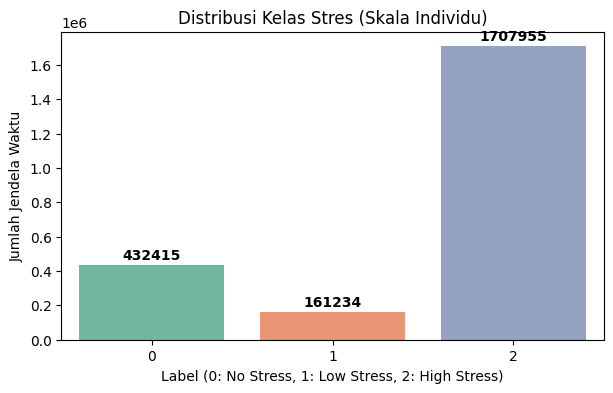

In [9]:
# Visualisasi EDA (Distribusi Kelas)
unik_label, jumlah_label = np.unique(y_3d, return_counts=True)
plt.figure(figsize=(7, 4))
sns.barplot(x=unik_label, y=jumlah_label, palette='Set2')
plt.title('Distribusi Kelas Stres (Skala Individu)')
plt.xlabel('Label (0: No Stress, 1: Low Stress, 2: High Stress)')
plt.ylabel('Jumlah Jendela Waktu')
for i, v in enumerate(jumlah_label):
    plt.text(i, v + (max(jumlah_label)*0.02), str(v), ha='center', fontweight='bold')
plt.show()

# Multiclass Subject-Independent

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
import gc

X_3d_mmap = np.load(path_simpan + 'X_vektor_60s.npy', mmap_mode='r')
y_3d_full = np.load(path_simpan + 'y_labels.npy')
groups_3d_full = np.load(path_simpan + 'groups_id.npy')

# GROUP SPLIT DILAKUKAN PERTAMA KALI (Mencegah Bias)
valid_split = False
percobaan = 0

while not valid_split:
    percobaan += 1
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42 + percobaan)
    train_idx, test_idx = next(gss.split(X_3d_mmap, y_3d_full, groups=groups_3d_full))

    # Memastikan test set memiliki ketiga kelas (0, 1, 2)
    if len(np.unique(y_3d_full[test_idx])) == 3:
        valid_split = True
        print(f"✅ Split ideal ditemukan pada percobaan ke-{percobaan}!")

X_train_raw = np.array(X_3d_mmap[train_idx], dtype='float32')
y_train_raw = y_3d_full[train_idx]

X_test = np.array(X_3d_mmap[test_idx], dtype='float32')
y_test = y_3d_full[test_idx]

# Bersihkan RAM dari file mmap raksasa
del X_3d_mmap, y_3d_full, groups_3d_full
gc.collect()

# UNDERSAMPLING HANYA PADA DATA LATIH
idx_0 = np.where(y_train_raw == 0)[0]
idx_1 = np.where(y_train_raw == 1)[0]
idx_2 = np.where(y_train_raw == 2)[0]

min_count = min(len(idx_0), len(idx_1), len(idx_2))

np.random.seed(42)
sampled_0 = np.random.choice(idx_0, min_count, replace=False)
sampled_1 = np.random.choice(idx_1, min_count, replace=False)
sampled_2 = np.random.choice(idx_2, min_count, replace=False)

train_selected_idx = np.concatenate([sampled_0, sampled_1, sampled_2])
np.random.shuffle(train_selected_idx)

# Timpa variabel agar hemat RAM
X_train = X_train_raw[train_selected_idx]
y_train = y_train_raw[train_selected_idx]

del X_train_raw, y_train_raw
gc.collect()

print(f"   -> Jumlah Data Latih: {len(X_train)} (Seimbang 1:1:1)")
print(f"   -> Jumlah Data Ujian: {len(X_test)} (Natural/Asli)")

# ARSITEKTUR MODEL (ANTI-OVERFITTING)
input_shape = (X_train.shape[1], X_train.shape[2])
jumlah_kelas = 3

model = Sequential([
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=64, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    LSTM(32, return_sequences=False),
    Dropout(0.5), # Hukuman Dropout di-set tinggi

    Dense(16, activation='relu'),
    Dense(jumlah_kelas, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# TRAINING & EVALUASI
early_stop = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1)

history_multiclass_independent = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# Evaluasi
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\nLaporan Klasifikasi (F1-Score, Precision, Recall):")
print(classification_report(y_test, y_pred))

✅ Split ideal ditemukan pada percobaan ke-2!
   -> Jumlah Data Latih: 431226 (Seimbang 1:1:1)
   -> Jumlah Data Ujian: 442415 (Natural/Asli)
Epoch 1/40
3369/3369 ━━━━━━━━━━━━━━━━━━━━ 164s 47ms/step - accuracy: 0.6990 - loss: 0.6749 - val_accuracy: 0.4785 - val_loss: 1.2100
Epoch 2/40
3369/3369 ━━━━━━━━━━━━━━━━━━━━ 214s 51ms/step - accuracy: 0.7928 - loss: 0.5049 - val_accuracy: 0.4723 - val_loss: 1.2630
Epoch 3/40
3369/3369 ━━━━━━━━━━━━━━━━━━━━ 196s 49ms/step - accuracy: 0.8167 - loss: 0.4510 - val_accuracy: 0.4769 - val_loss: 1.3184
Epoch 4/40
3369/3369 ━━━━━━━━━━━━━━━━━━━━ 160s 48ms/step - accuracy: 0.8320 - loss: 0.4168 - val_accuracy: 0.4862 - val_loss: 1.3518
Epoch 5/40
3369/3369 ━━━━━━━━━━━━━━━━━━━━ 162s 48ms/step - accuracy: 0.8424 - loss: 0.3955 - val_accuracy: 0.4807 - val_loss: 1.3244
Epoch 6/40
3369/3369 ━━━━━━━━━━━━━━━━━━━━ 163s 48ms/step - accuracy: 0.8505 - loss: 0.3779 - val_accuracy: 0.5066 - val_loss: 1.3326
Epoch 7/40
3369/3369 ━━━━━━━━━━━━━━━━━━━━ 170s 50ms/step - ac

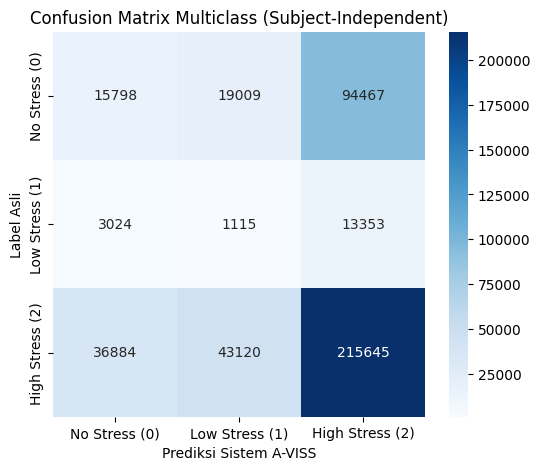

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stress (0)', 'Low Stress (1)', 'High Stress (2)'],
            yticklabels=['No Stress (0)', 'Low Stress (1)', 'High Stress (2)'])
plt.title('Confusion Matrix Multiclass (Subject-Independent)')
plt.xlabel('Prediksi Sistem A-VISS')
plt.ylabel('Label Asli')
plt.show()

# Multiclass Subject-Dependent

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
import gc

X_3d_mmap = np.load(path_simpan + 'X_vektor_60s.npy', mmap_mode='r')
y_3d_full = np.load(path_simpan + 'y_labels.npy')
# Note: groups_id.npy tidak di-load karena kita tidak lagi memisahkan berdasarkan pasien

# RANDOM SPLIT (SUBJECT-DEPENDENT)
train_idx, test_idx = train_test_split(
    np.arange(len(y_3d_full)),
    test_size=0.2,
    random_state=42,
    stratify=y_3d_full
)

X_train_raw = np.array(X_3d_mmap[train_idx], dtype='float32')
y_train_raw = y_3d_full[train_idx]

X_test = np.array(X_3d_mmap[test_idx], dtype='float32')
y_test = y_3d_full[test_idx]

# Bersihkan RAM dari file memori virtual raksasa
del X_3d_mmap, y_3d_full
gc.collect()

# UNDERSAMPLING HANYA PADA DATA LATIH
idx_0 = np.where(y_train_raw == 0)[0]
idx_1 = np.where(y_train_raw == 1)[0]
idx_2 = np.where(y_train_raw == 2)[0]

min_count = min(len(idx_0), len(idx_1), len(idx_2))

np.random.seed(42)
sampled_0 = np.random.choice(idx_0, min_count, replace=False)
sampled_1 = np.random.choice(idx_1, min_count, replace=False) # Kelas minoritas ambil semua sesuai limit
sampled_2 = np.random.choice(idx_2, min_count, replace=False)

train_selected_idx = np.concatenate([sampled_0, sampled_1, sampled_2])
np.random.shuffle(train_selected_idx)

# Bentuk data latih akhir yang sudah seimbang
X_train = X_train_raw[train_selected_idx]
y_train = y_train_raw[train_selected_idx]

del X_train_raw, y_train_raw
gc.collect()

print(f"   -> Jumlah Data Latih Akhir: {len(X_train)} data (Seimbang 1:1:1)")
print(f"   -> Jumlah Data Ujian Akhir: {len(X_test)} data (Natural/Stratified)")

# ARSITEKTUR MODEL
input_shape = (X_train.shape[1], X_train.shape[2])
jumlah_kelas = 3

model = Sequential([
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=64, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    LSTM(32, return_sequences=False),
    Dropout(0.5),

    Dense(16, activation='relu'),
    Dense(jumlah_kelas, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# TRAINING & EVALUASI
early_stop = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1)

history_multiclass_dependent = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# Evaluasi
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\nLaporan Klasifikasi (F1-Score, Precision, Recall):")
print(classification_report(y_test, y_pred))

   -> Jumlah Data Latih Akhir: 386961 data (Seimbang 1:1:1)
   -> Jumlah Data Ujian Akhir: 460321 data (Natural/Stratified)
Epoch 1/40
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 160s 51ms/step - accuracy: 0.6401 - loss: 0.7793 - val_accuracy: 0.6321 - val_loss: 0.7394
Epoch 2/40
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 198s 50ms/step - accuracy: 0.7330 - loss: 0.6172 - val_accuracy: 0.6848 - val_loss: 0.6706
Epoch 3/40
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 153s 51ms/step - accuracy: 0.7607 - loss: 0.5613 - val_accuracy: 0.6975 - val_loss: 0.6324
Epoch 4/40
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 160s 53ms/step - accuracy: 0.7766 - loss: 0.5292 - val_accuracy: 0.7716 - val_loss: 0.5057
Epoch 5/40
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 151s 50ms/step - accuracy: 0.7883 - loss: 0.5041 - val_accuracy: 0.7517 - val_loss: 0.5476
Epoch 6/40
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 152s 50ms/step - accuracy: 0.7957 - loss: 0.4885 - val_accuracy: 0.7506 - val_loss: 0.5467
Epoch 7/40
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 204s 51ms/step - accuracy: 0.8022 - 

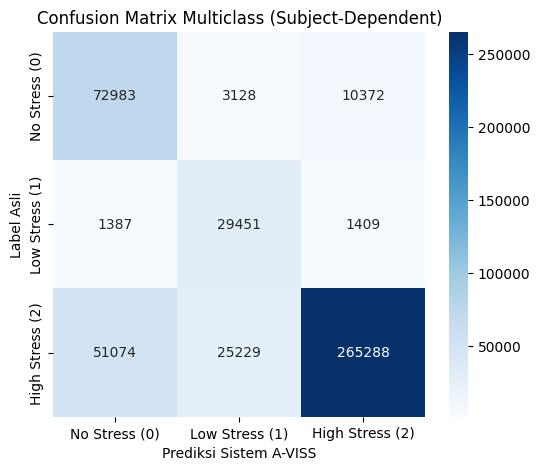

In [13]:
# Visualisasi dengan label baru yang sudah diperbaiki
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stress (0)', 'Low Stress (1)', 'High Stress (2)'],
            yticklabels=
             ['No Stress (0)', 'Low Stress (1)', 'High Stress (2)'])
plt.title('Confusion Matrix Multiclass (Subject-Dependent)')
plt.xlabel('Prediksi Sistem A-VISS')
plt.ylabel('Label Asli')
plt.show()

## Binary Subject-Independent

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# TRAINING (KLASIFIKASI BINER & SUBJECT-INDEPENDENT)
X_3d_mmap = np.load(path_simpan + 'X_vektor_60s.npy', mmap_mode='r')
y_3d_full = np.load(path_simpan + 'y_labels.npy')
groups_3d_full = np.load(path_simpan + 'groups_id.npy')

# TRANSFORMASI LABEL BINER
y_biner = np.where(y_3d_full == 2, 1, 0)

valid_split = False
percobaan = 0

while not valid_split:
    percobaan += 1
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42 + percobaan)
    train_idx, test_idx = next(gss.split(X_3d_mmap, y_biner, groups=groups_3d_full))

    if len(np.unique(y_biner[test_idx])) == 2:
        valid_split = True

X_train_raw = np.array(X_3d_mmap[train_idx], dtype='float32')
y_train_raw = y_biner[train_idx]

X_test = np.array(X_3d_mmap[test_idx], dtype='float32')
y_test = y_biner[test_idx]

del X_3d_mmap, y_3d_full, groups_3d_full, y_biner
gc.collect()

# UNDERSAMPLING
idx_0, idx_1 = np.where(y_train_raw == 0)[0], np.where(y_train_raw == 1)[0]

min_count = min(len(idx_0), len(idx_1))

np.random.seed(42)
sampled_0 = np.random.choice(idx_0, min_count, replace=False)
sampled_1 = np.random.choice(idx_1, min_count, replace=False)

train_selected_idx = np.concatenate([sampled_0, sampled_1])
np.random.shuffle(train_selected_idx)

X_train, y_train = X_train_raw[train_selected_idx], y_train_raw[train_selected_idx]

del X_train_raw, y_train_raw
gc.collect()

# ARSITEKTUR
model_ind = Sequential([
    Conv1D(32, 5, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(64, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    LSTM(32),
    Dropout(0.5),

    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_ind.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1)

# SIMPAN KE history_independent
history_binary_independent = model_ind.fit(
    X_train, y_train, epochs=20, batch_size=256,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)],
    verbose=1
)

y_pred = (model_ind.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Stress']))

Epoch 1/20
4287/4287 ━━━━━━━━━━━━━━━━━━━━ 304s 70ms/step - accuracy: 0.7644 - loss: 0.4645 - val_accuracy: 0.6297 - val_loss: 0.8844
Epoch 2/20
4287/4287 ━━━━━━━━━━━━━━━━━━━━ 310s 72ms/step - accuracy: 0.8298 - loss: 0.3661 - val_accuracy: 0.6471 - val_loss: 0.9054
Epoch 3/20
4287/4287 ━━━━━━━━━━━━━━━━━━━━ 293s 68ms/step - accuracy: 0.8486 - loss: 0.3319 - val_accuracy: 0.6286 - val_loss: 0.9787
Epoch 4/20
4287/4287 ━━━━━━━━━━━━━━━━━━━━ 292s 68ms/step - accuracy: 0.8582 - loss: 0.3132 - val_accuracy: 0.6558 - val_loss: 0.9120
Epoch 5/20
4287/4287 ━━━━━━━━━━━━━━━━━━━━ 291s 68ms/step - accuracy: 0.8658 - loss: 0.2986 - val_accuracy: 0.6460 - val_loss: 0.9837
Epoch 6/20
4287/4287 ━━━━━━━━━━━━━━━━━━━━ 310s 72ms/step - accuracy: 0.8704 - loss: 0.2879 - val_accuracy: 0.6604 - val_loss: 0.9465
Epoch 7/20
4287/4287 ━━━━━━━━━━━━━━━━━━━━ 300s 70ms/step - accuracy: 0.8751 - loss: 0.2786 - val_accuracy: 0.6602 - val_loss: 0.9518
Epoch 8/20
4287/4287 ━━━━━━━━━━━━━━━━━━━━ 323s 70ms/step - accuracy: 

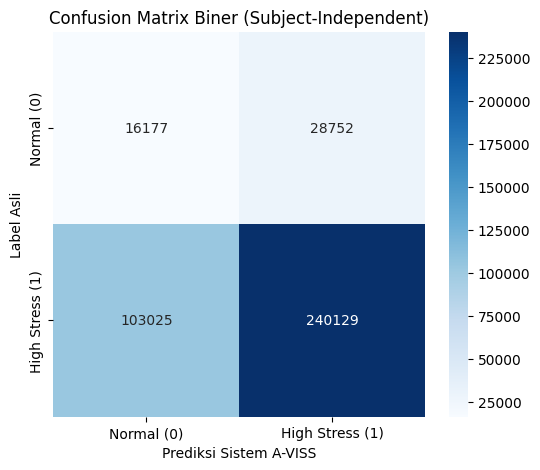

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'High Stress (1)'],
            yticklabels=['Normal (0)', 'High Stress (1)'])
plt.title('Confusion Matrix Biner (Subject-Independent)')
plt.xlabel('Prediksi Sistem A-VISS')
plt.ylabel('Label Asli')
plt.show()

# Binary Subject-Dependent

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import EarlyStopping
import gc

# TRAINING (KLASIFIKASI BINER & SUBJECT-DEPENDENT)
X_3d_mmap = np.load(path_simpan + 'X_vektor_60s.npy', mmap_mode='r')
y_3d_full = np.load(path_simpan + 'y_labels.npy')

# TRANSFORMASI LABEL MENJADI BINER (Sesuai Permintaan Dosen)
# Logika: Jika y asli adalah 2, jadikan 1 (High Stress). Jika bukan, jadikan 0 (Normal).
y_biner = np.where(y_3d_full == 2, 1, 0)

unik, jumlah = np.unique(y_biner, return_counts=True)
print(f"   -> Label 0 (Normal / Not High Stress): {jumlah[0]} data")
print(f"   -> Label 1 (High Stress): {jumlah[1]} data")

# SPLIT DATA (Subject-Dependent)
train_idx, test_idx = train_test_split(
    np.arange(len(y_biner)),
    test_size=0.2,
    random_state=42,
    stratify=y_biner
)

X_train_raw = np.array(X_3d_mmap[train_idx], dtype='float32')
y_train_raw = y_biner[train_idx]

X_test = np.array(X_3d_mmap[test_idx], dtype='float32')
y_test = y_biner[test_idx]

del X_3d_mmap, y_3d_full, y_biner
gc.collect()

# UNDERSAMPLING HANYA PADA DATA LATIH
idx_0 = np.where(y_train_raw == 0)[0]
idx_1 = np.where(y_train_raw == 1)[0]

# Karena sekarang Label 1 (High Stress) sangat banyak (1,7 juta),
# kita potong mengikuti jumlah Label 0 (Normal) yang sekitar 593 ribu.
min_count = min(len(idx_0), len(idx_1))

np.random.seed(42)
sampled_0 = np.random.choice(idx_0, min_count, replace=False)
sampled_1 = np.random.choice(idx_1, min_count, replace=False)

train_selected_idx = np.concatenate([sampled_0, sampled_1])
np.random.shuffle(train_selected_idx)

X_train = X_train_raw[train_selected_idx]
y_train = y_train_raw[train_selected_idx]

del X_train_raw, y_train_raw
gc.collect()
print(f"   -> Data Latih Akhir: {len(X_train)} data (Seimbang 50:50)")

# ARSITEKTUR MODEL (Versi Biner)
input_shape = (X_train.shape[1], X_train.shape[2])

model = Sequential([
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=64, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    LSTM(32, return_sequences=False),
    Dropout(0.5),

    Dense(16, activation='relu'),
    # PERUBAHAN PENTING: Gunakan 1 Neuron dan Sigmoid untuk 2 Kelas
    Dense(1, activation='sigmoid')
])

# PERUBAHAN PENTING: Gunakan binary_crossentropy
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# TRAINING & EVALUASI
early_stop = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1)

print("\n🚀 Memulai Pelatihan Model Biner A-VISS")
history_binary_dependent = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# Evaluasi
# Karena outputnya sigmoid (0.0 sampai 1.0), kita bulatkan ke 0 atau 1
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'High Stress (1)']))

   -> Label 0 (Normal / Not High Stress): 593649 data
   -> Label 1 (High Stress): 1707955 data
   -> Data Latih Akhir: 949838 data (Seimbang 50:50)

🚀 Memulai Pelatihan Model Biner A-VISS
Epoch 1/40
7421/7421 ━━━━━━━━━━━━━━━━━━━━ 98s 12ms/step - accuracy: 0.7440 - loss: 0.4952 - val_accuracy: 0.7987 - val_loss: 0.4139
Epoch 2/40
7421/7421 ━━━━━━━━━━━━━━━━━━━━ 90s 12ms/step - accuracy: 0.8065 - loss: 0.4031 - val_accuracy: 0.8222 - val_loss: 0.3818
Epoch 3/40
7421/7421 ━━━━━━━━━━━━━━━━━━━━ 91s 12ms/step - accuracy: 0.8250 - loss: 0.3732 - val_accuracy: 0.8310 - val_loss: 0.3578
Epoch 4/40
7421/7421 ━━━━━━━━━━━━━━━━━━━━ 90s 12ms/step - accuracy: 0.8356 - loss: 0.3540 - val_accuracy: 0.8411 - val_loss: 0.3457
Epoch 5/40
7421/7421 ━━━━━━━━━━━━━━━━━━━━ 88s 12ms/step - accuracy: 0.8427 - loss: 0.3406 - val_accuracy: 0.8460 - val_loss: 0.3352
Epoch 6/40
7421/7421 ━━━━━━━━━━━━━━━━━━━━ 90s 12ms/step - accuracy: 0.8485 - loss: 0.3306 - val_accuracy: 0.8436 - val_loss: 0.3380
Epoch 7/40
7421/742

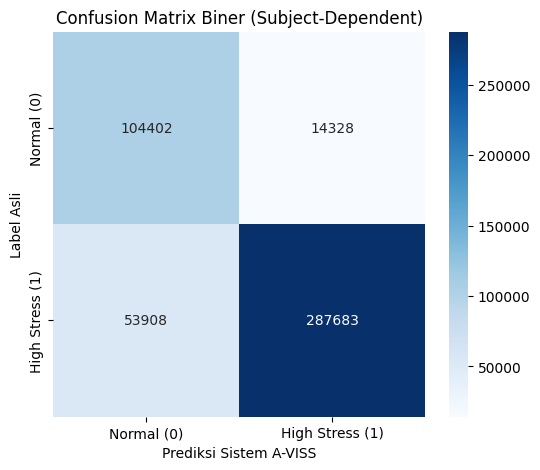

In [4]:
from sklearn.metrics import confusion_matrix

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'High Stress (1)'],
            yticklabels=['Normal (0)', 'High Stress (1)'])
plt.title('Confusion Matrix Biner (Subject-Dependent)')
plt.xlabel('Prediksi Sistem A-VISS')
plt.ylabel('Label Asli')
plt.show()

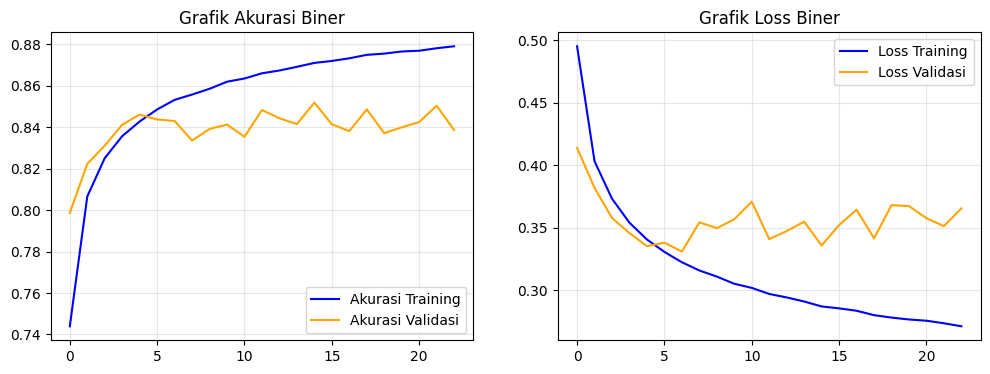

In [5]:
# Grafik Training History (Sekaligus agar tidak hilang lagi)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_binary_dependent.history['accuracy'], label='Akurasi Training', color='blue')
plt.plot(history_binary_dependent.history['val_accuracy'], label='Akurasi Validasi', color='orange')
plt.title('Grafik Akurasi Biner')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_binary_dependent.history['loss'], label='Loss Training', color='blue')
plt.plot(history_binary_dependent.history['val_loss'], label='Loss Validasi', color='orange')
plt.title('Grafik Loss Biner')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Model Comparison

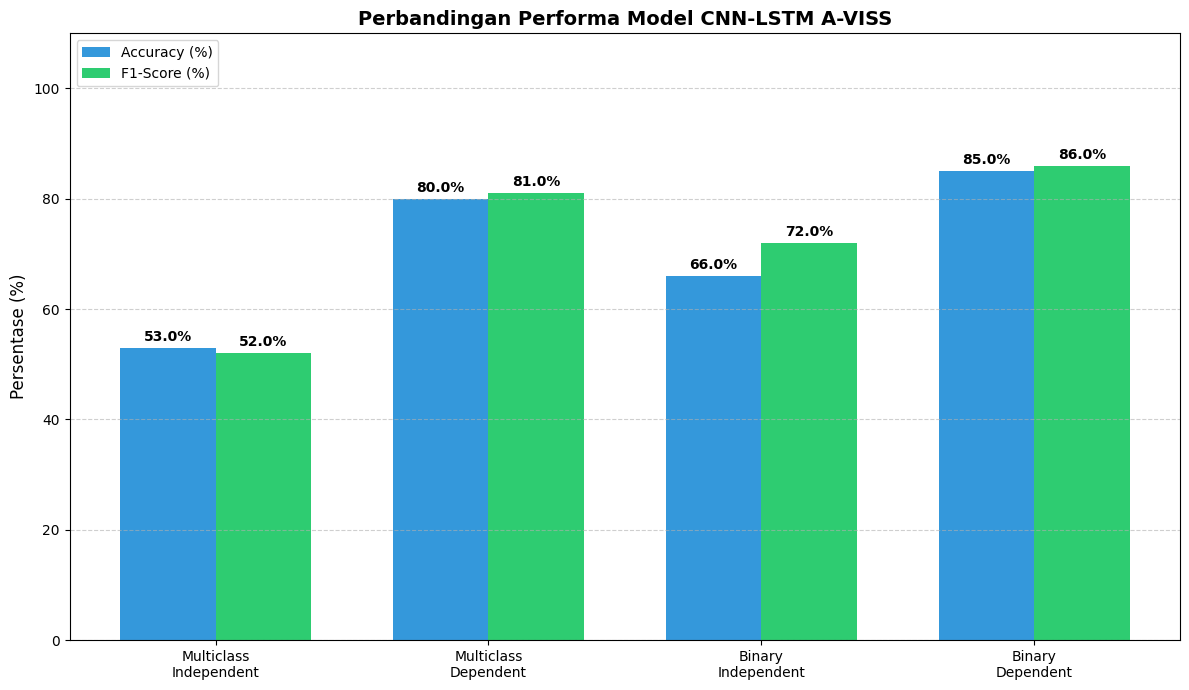

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Data berdasarkan hasil laporan klasifikasi yang diberikan
labels = [
    'Multiclass\nIndependent',
    'Multiclass\nDependent',
    'Binary\nIndependent',
    'Binary\nDependent'
]

# Nilai Akurasi (Accuracy) dari log
accuracies = [53.0, 80.0, 66.0, 85.0]

# Nilai F1-Score (Weighted Avg) dari log
f1_scores = [52.0, 81.0, 72.0, 86.0]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy (%)', color='#3498db')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score (%)', color='#2ecc71')

# Tambahkan label dan judul
ax.set_ylabel('Persentase (%)', fontsize=12)
ax.set_title('Perbandingan Performa Model CNN-LSTM A-VISS', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 110)
ax.legend(loc='upper left')

# Fungsi untuk menampilkan angka di atas batang
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Import Model

In [2]:
# Simpan model final

model.save(
    '/content/drive/MyDrive/A-VISS/model_binary_subject_dependent.keras'
)

print("✅ Model berhasil disimpan")

✅ Model berhasil disimpan


In [9]:
feature_columns = [
    'HR',
    'EDA',
    'TEMP',
    'X',
    'Y',
    'Z'
]

import pickle

with open(
    '/content/drive/MyDrive/A-VISS/features.pkl',
    'wb'
) as f:

    pickle.dump(
        feature_columns,
        f
    )

print("✅ Feature list tersimpan")

✅ Feature list tersimpan
